In [82]:
from pathlib import Path
import pandas as pd

# Base folder where all experiments are saved
BASE_DIR = Path(r"C:\Users\user\BIO MEDICAL ROBOTICS Dropbox\Elisheva Shiri Decktor\BGU\Codes\Parallel_Heptics\debug_experiments")

# --- Selection of which experiment folder to read ---
# 0  -> first experiment folder
# 1  -> second experiment folder
# 2  -> third experiment folder
# ...
# -1 -> last (most recent / highest index) experiment folder
EXPERIMENT_INDEX = -1  # change this value as you like

# --- Helper: get all experiment folders ---
experiment_dirs = sorted(
    [d for d in BASE_DIR.iterdir() if d.is_dir()],
    key=lambda p: p.name  # names already contain timestamp + index
)

if not experiment_dirs:
    raise FileNotFoundError(f"No experiment folders found under: {BASE_DIR}")

selected_experiment = experiment_dirs[EXPERIMENT_INDEX]
print(f"Selected experiment folder: {selected_experiment}")

# Inside each experiment there are sub-folders pair_000, pair_001, ...
pair_dirs = sorted(
    [d for d in selected_experiment.iterdir() if d.is_dir() and d.name.startswith("pair_")],
    key=lambda p: p.name,
)

if not pair_dirs:
    raise FileNotFoundError(f"No 'pair_*' folders found in experiment: {selected_experiment}")

# By default, take the last pair (highest index). Change PAIR_INDEX if you want another one.
# 0, 1, 2, ... or -1 for last
PAIR_INDEX = -1
selected_pair = pair_dirs[PAIR_INDEX]
print(f"Selected pair folder: {selected_pair}")

tracking_csv = selected_pair / "tracking.csv"
if not tracking_csv.exists():
    raise FileNotFoundError(f"tracking.csv not found at: {tracking_csv}")

print(f"Reading: {tracking_csv}")
df = pd.read_csv(tracking_csv)

# Quick preview of the data
df.head()


Selected experiment folder: C:\Users\user\BIO MEDICAL ROBOTICS Dropbox\Elisheva Shiri Decktor\BGU\Codes\Parallel_Heptics\debug_experiments\2025_12_15_15_25_middle_020
Selected pair folder: C:\Users\user\BIO MEDICAL ROBOTICS Dropbox\Elisheva Shiri Decktor\BGU\Codes\Parallel_Heptics\debug_experiments\2025_12_15_15_25_middle_020\pair_001
Reading: C:\Users\user\BIO MEDICAL ROBOTICS Dropbox\Elisheva Shiri Decktor\BGU\Codes\Parallel_Heptics\debug_experiments\2025_12_15_15_25_middle_020\pair_001\tracking.csv


,timestamp,interacting,stiffness,object_x,object_y,finger,thumb_x,thumb_y,active_finger_x,active_finger_y,dt,thumb_vx,thumb_vy,active_finger_vx,active_finger_vy,thumb_avg_vx,thumb_avg_vy,active_finger_avg_vx,active_finger_avg_vy
0,2025-12-15T15:25:52.710113,False,0,320.0,240.0,index,182.564316,141.906767,196.891060,142.011094,NaN,NaN,NaN,NaN,NaN,-15.178896,-7.241394,-14.623542,-6.838641
1,2025-12-15T15:25:52.785859,False,85,320.0,240.0,index,182.178078,148.968287,189.726830,148.457766,0.075746,-5.099118,93.226231,-94.582219,85.109002,-15.178896,-7.241394,-14.623542,-6.838641
2,2025-12-15T15:25:52.809187,False,85,320.0,240.0,index,185.329666,177.793765,210.504341,170.457201,0.023328,135.098574,1235.656600,890.665849,943.045838,-15.178896,-7.241394,-14.623542,-6.838641
3,2025-12-15T15:25:52.840352,False,85,320.0,240.0,index,177.402954,195.535326,205.770569,183.528156,0.031165,-254.347550,569.280496,-151.894427,419.412921,-15.178896,-7.241394,-14.623542,-6.838641
4,2025-12-15T15:25:52.862617,False,85,320.0,240.0,index,183.647270,199.284039,209.857788,183.600998,0.022265,280.454886,168.368278,183.571842,3.271582,-15.178896,-7.241394,-14.623542,-6.838641


In [83]:

import numpy as np

from pathlib import Path

# Create a new column for calculations (leave original 'timestamp' unchanged)
df['timestamp_diffcalc'] = pd.to_datetime(df['timestamp'])

# Ensure sorted by the timestamp used for calculations
df = df.sort_values('timestamp_diffcalc').reset_index(drop=True)

# Convert to numeric (total seconds since epoch) to preserve full precision
# This maintains microsecond precision (6 decimal places)
df['timestamp_numeric'] = (df['timestamp_diffcalc'] - pd.Timestamp('1970-01-01')).dt.total_seconds()

# Time difference in seconds with full precision (preserves microsecond precision)
df['dt'] = df['timestamp_numeric'].diff()

# ============================================================================
# DIAGNOSTIC: Check dt distribution to understand velocity spikes
# ============================================================================
print("=" * 60)
print("DIAGNOSTIC: Time delta (dt) statistics")
print("=" * 60)
print(f"dt min:    {df['dt'].min():.6f} seconds")
print(f"dt max:    {df['dt'].max():.6f} seconds")
print(f"dt mean:   {df['dt'].mean():.6f} seconds")
print(f"dt median: {df['dt'].median():.6f} seconds")
print(f"dt std:    {df['dt'].std():.6f} seconds")
print(f"\nRows with dt < 0.001s (1ms): {(df['dt'] < 0.001).sum()}")
print(f"Rows with dt < 0.01s (10ms): {(df['dt'] < 0.01).sum()}")
print(f"Rows with dt == 0:           {(df['dt'] == 0).sum()}")

# ============================================================================
# VELOCITY CALCULATION WITH OUTLIER FILTERING
# ============================================================================
# Set minimum dt threshold to avoid division by very small numbers
MIN_DT_THRESHOLD = 0.005  # 5ms minimum - adjust if needed

# Differences for thumb and active finger
df['thumb_dx'] = df['thumb_x'].diff()
df['thumb_dy'] = df['thumb_y'].diff()
df['active_finger_dx'] = df['active_finger_x'].diff()
df['active_finger_dy'] = df['active_finger_y'].diff()

# Calculate raw velocity
df['thumb_vx_raw'] = df['thumb_dx'] / df['dt']
df['thumb_vy_raw'] = df['thumb_dy'] / df['dt']
df['active_finger_vx_raw'] = df['active_finger_dx'] / df['dt']
df['active_finger_vy_raw'] = df['active_finger_dy'] / df['dt']

# Apply dt threshold: set velocity to NaN where dt is too small
mask_valid_dt = df['dt'] >= MIN_DT_THRESHOLD

# Also filter out velocity outliers (likely tracking jumps)
# Using percentile-based filtering: remove values beyond 99th percentile
VELOCITY_PERCENTILE_THRESHOLD = 99  # Remove top 1% as outliers

def filter_velocity_outliers(velocity_series, percentile=99):
    """Replace extreme outliers with NaN based on percentile threshold."""
    threshold = np.nanpercentile(np.abs(velocity_series), percentile)
    filtered = velocity_series.copy()
    filtered[np.abs(filtered) > threshold] = np.nan
    return filtered, threshold

# Apply both filters: dt threshold AND velocity outlier removal
df['thumb_vx'] = df['thumb_vx_raw'].where(mask_valid_dt, np.nan)
df['thumb_vy'] = df['thumb_vy_raw'].where(mask_valid_dt, np.nan)
df['active_finger_vx'] = df['active_finger_vx_raw'].where(mask_valid_dt, np.nan)
df['active_finger_vy'] = df['active_finger_vy_raw'].where(mask_valid_dt, np.nan)

# Filter outliers
df['thumb_vx'], thumb_vx_thresh = filter_velocity_outliers(df['thumb_vx'], VELOCITY_PERCENTILE_THRESHOLD)
df['thumb_vy'], thumb_vy_thresh = filter_velocity_outliers(df['thumb_vy'], VELOCITY_PERCENTILE_THRESHOLD)
df['active_finger_vx'], af_vx_thresh = filter_velocity_outliers(df['active_finger_vx'], VELOCITY_PERCENTILE_THRESHOLD)
df['active_finger_vy'], af_vy_thresh = filter_velocity_outliers(df['active_finger_vy'], VELOCITY_PERCENTILE_THRESHOLD)

print(f"\n" + "=" * 60)
print("FILTERING APPLIED")
print("=" * 60)
print(f"Minimum dt threshold: {MIN_DT_THRESHOLD*1000:.1f} ms")
print(f"Velocity outlier percentile: {VELOCITY_PERCENTILE_THRESHOLD}%")
print(f"\nVelocity thresholds (|v| > threshold set to NaN):")
print(f"  thumb_vx:         {thumb_vx_thresh:.2f} pixels/s")
print(f"  thumb_vy:         {thumb_vy_thresh:.2f} pixels/s")
print(f"  active_finger_vx: {af_vx_thresh:.2f} pixels/s")
print(f"  active_finger_vy: {af_vy_thresh:.2f} pixels/s")

# Average velocities (ignoring NaN)
thumb_vx_mean = df['thumb_vx'].mean()
thumb_vy_mean = df['thumb_vy'].mean()
active_finger_vx_mean = df['active_finger_vx'].mean()
active_finger_vy_mean = df['active_finger_vy'].mean()

print(f"\n" + "=" * 60)
print("FILTERED VELOCITY RESULTS")
print("=" * 60)
print(f"Thumb mean vx: {thumb_vx_mean:.6f} pixels/s, vy: {thumb_vy_mean:.6f} pixels/s")
print(f"Active finger mean vx: {active_finger_vx_mean:.6f} pixels/s, vy: {active_finger_vy_mean:.6f} pixels/s")
print(f"\nValid velocity samples: {df['thumb_vx'].notna().sum()} out of {len(df)} ({100*df['thumb_vx'].notna().sum()/len(df):.1f}%)")

# -- Save separate CSVs for thumb and for each active finger (index, middle, ring) --

out_dir = tracking_csv.parent  # same folder as tracking.csv

# 1. Save thumb trajectory/velocity data
thumb_cols = ['timestamp', 'timestamp_diffcalc', 'timestamp_numeric', 'dt', 'thumb_x', 'thumb_y', 'thumb_dx', 'thumb_dy', 'thumb_vx', 'thumb_vy']
thumb_df = df[thumb_cols].copy()
thumb_csv_path = out_dir / "thumb_kinematics.csv"
thumb_df.to_csv(thumb_csv_path, index=False)
print(f"Saved thumb velocities: {thumb_csv_path}")

# 2. Save for each active finger type (index, middle, ring)
active_finger_types = ["index", "middle", "ring"]
active_cols = ['timestamp', 'timestamp_diffcalc', 'timestamp_numeric', 'dt',
               'active_finger_x', 'active_finger_y', 'active_finger_dx', 'active_finger_dy',
               'active_finger_vx', 'active_finger_vy', 'finger']

for finger in active_finger_types:
    # Filter rows for the current finger type
    finger_df = df[df['finger'] == finger][active_cols].copy()
    if not finger_df.empty:
        out_csv = out_dir / f"{finger}_kinematics.csv"
        finger_df.to_csv(out_csv, index=False)
        print(f"Saved {finger} active finger velocities: {out_csv}")



DIAGNOSTIC: Time delta (dt) statistics
dt min:    0.002510 seconds
dt max:    0.250270 seconds
dt mean:   0.035100 seconds
dt median: 0.032607 seconds
dt std:    0.007173 seconds

Rows with dt < 0.001s (1ms): 0
Rows with dt < 0.01s (10ms): 10
Rows with dt == 0:           0

FILTERING APPLIED
Minimum dt threshold: 5.0 ms
Velocity outlier percentile: 99%

Velocity thresholds (|v| > threshold set to NaN):
  thumb_vx:         721.89 pixels/s
  thumb_vy:         622.17 pixels/s
  active_finger_vx: 902.39 pixels/s
  active_finger_vy: 685.48 pixels/s

FILTERED VELOCITY RESULTS
Thumb mean vx: 0.228603 pixels/s, vy: -1.408903 pixels/s
Active finger mean vx: -0.567509 pixels/s, vy: -0.954660 pixels/s

Valid velocity samples: 15549 out of 15716 (98.9%)
Saved thumb velocities: C:\Users\user\BIO MEDICAL ROBOTICS Dropbox\Elisheva Shiri Decktor\BGU\Codes\Parallel_Heptics\debug_experiments\2025_12_15_15_25_middle_020\pair_001\thumb_kinematics.csv
Saved index active finger velocities: C:\Users\user\BIO

In [84]:
# --- Save the updated DataFrame with velocity columns back to tracking.csv ---

# Select which columns to keep in the updated tracking.csv
# Original columns + velocity-related columns
columns_to_save = [
    # Original columns from tracking.csv
    'timestamp', 'interacting', 'stiffness', 'object_x', 'object_y', 'finger',
    'thumb_x', 'thumb_y', 'active_finger_x', 'active_finger_y',
    # New velocity columns
    'dt',  # time delta between frames (seconds)
    'thumb_vx', 'thumb_vy',  # thumb velocity components
    'active_finger_vx', 'active_finger_vy',  # active finger velocity components
]

# Filter only columns that exist in df
existing_cols = [c for c in columns_to_save if c in df.columns]

# Also add any other original columns that might exist (from position_dict)
original_cols_in_df = [c for c in df.columns if c not in existing_cols 
                       and c not in ['timestamp_diffcalc', 'timestamp_numeric', 
                                     'thumb_dx', 'thumb_dy', 'active_finger_dx', 'active_finger_dy',
                                     'time_rel']]
final_cols = existing_cols + original_cols_in_df

# Create the output DataFrame
df_to_save = df[final_cols].copy()

# Add mean velocity columns (constant values for reference)
df_to_save['thumb_avg_vx'] = thumb_vx_mean
df_to_save['thumb_avg_vy'] = thumb_vy_mean
df_to_save['active_finger_avg_vx'] = active_finger_vx_mean
df_to_save['active_finger_avg_vy'] = active_finger_vy_mean

# Save back to the original tracking.csv
df_to_save.to_csv(tracking_csv, index=False)
print(f"Updated tracking.csv saved to: {tracking_csv}")
print(f"\nNew columns added:")
print(f"  - dt: time delta between frames (seconds)")
print(f"  - thumb_vx, thumb_vy: instantaneous thumb velocity (pixels/s)")
print(f"  - active_finger_vx, active_finger_vy: instantaneous active finger velocity (pixels/s)")
print(f"  - thumb_avg_vx, thumb_avg_vy: average thumb velocity over entire recording")
print(f"  - active_finger_avg_vx, active_finger_avg_vy: average active finger velocity over entire recording")
print(f"\nTotal rows: {len(df_to_save)}, Total columns: {len(df_to_save.columns)}")
print(f"Columns: {list(df_to_save.columns)}")


Updated tracking.csv saved to: C:\Users\user\BIO MEDICAL ROBOTICS Dropbox\Elisheva Shiri Decktor\BGU\Codes\Parallel_Heptics\debug_experiments\2025_12_15_15_25_middle_020\pair_001\tracking.csv

New columns added:
  - dt: time delta between frames (seconds)
  - thumb_vx, thumb_vy: instantaneous thumb velocity (pixels/s)
  - active_finger_vx, active_finger_vy: instantaneous active finger velocity (pixels/s)
  - thumb_avg_vx, thumb_avg_vy: average thumb velocity over entire recording
  - active_finger_avg_vx, active_finger_avg_vy: average active finger velocity over entire recording

Total rows: 15716, Total columns: 23
Columns: ['timestamp', 'interacting', 'stiffness', 'object_x', 'object_y', 'finger', 'thumb_x', 'thumb_y', 'active_finger_x', 'active_finger_y', 'dt', 'thumb_vx', 'thumb_vy', 'active_finger_vx', 'active_finger_vy', 'thumb_avg_vx', 'thumb_avg_vy', 'active_finger_avg_vx', 'active_finger_avg_vy', 'thumb_vx_raw', 'thumb_vy_raw', 'active_finger_vx_raw', 'active_finger_vy_raw']


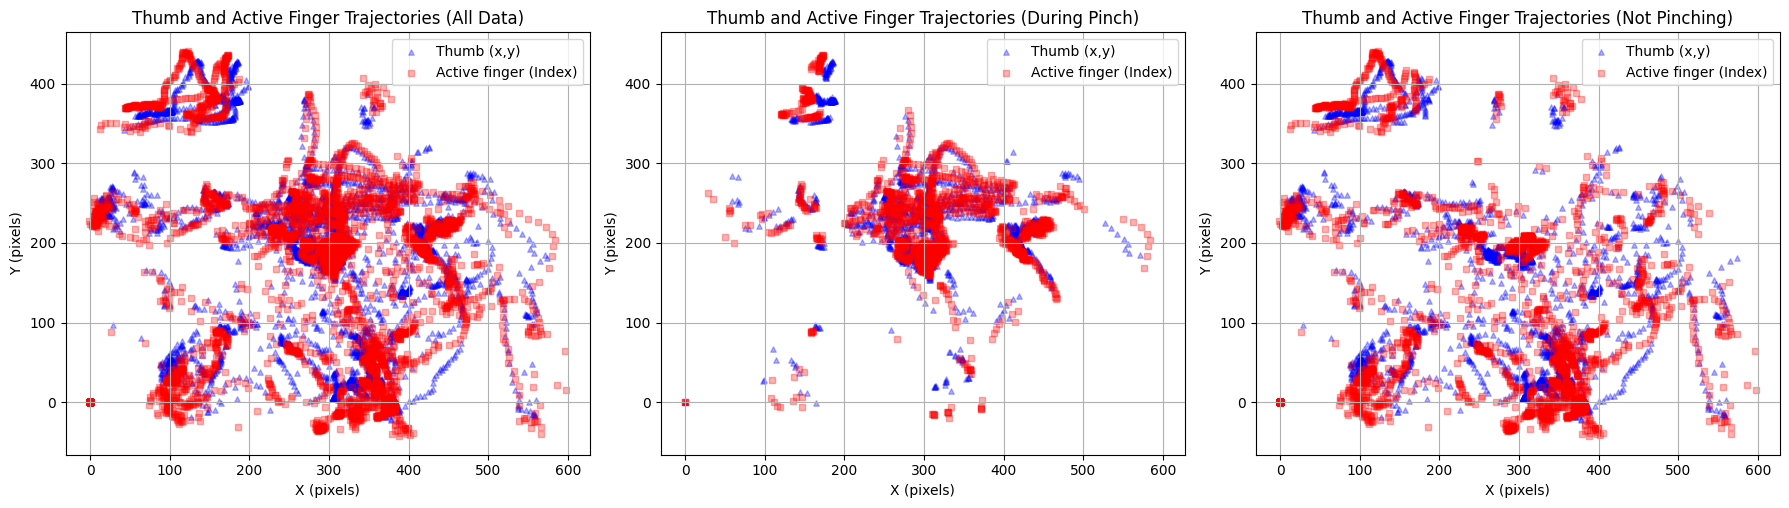

In [85]:


import matplotlib.pyplot as plt
import numpy as np

def plot_finger_trajectories(df, figsize=(18, 6)):
    """
    Plot thumb and active finger trajectories in three subplots:
    1. All data
    2. During interaction
    3. When not interacting
    
    All subplots share the same axis limits for easy comparison.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame with columns: thumb_x, thumb_y, active_finger_x, active_finger_y, finger, interacting
    figsize : tuple, optional
        Figure size (width, height). Default is (18, 6) for three side-by-side plots.
    """
    # Check required columns
    required_cols = {"thumb_x", "thumb_y", "active_finger_x", "active_finger_y", "finger"}
    missing = required_cols.difference(df.columns)
    if missing:
        raise ValueError(f"Missing required columns in df: {missing}")
    
    # Finger style mapping
    finger_style = {
        "index": ("red", "s", "Active finger (Index)"),        # red square
        "middle": ("#90ee90", "*", "Active finger (Middle)"),   # light green star
        "ring": ("darkgreen", "o", "Active finger (Ring)"),    # dark green circle
    }
    
    scatter_size = 18
    thumb_alpha = 0.3
    finger_alpha = 0.3
    
    # Calculate common axis limits from all data
    all_x = np.concatenate([df["thumb_x"].values, df["active_finger_x"].values])
    all_y = np.concatenate([df["thumb_y"].values, df["active_finger_y"].values])
    
    x_min, x_max = all_x.min(), all_x.max()
    y_min, y_max = all_y.min(), all_y.max()
    
    # Add small margin
    x_margin = (x_max - x_min) * 0.05
    y_margin = (y_max - y_min) * 0.05
    x_min -= x_margin
    x_max += x_margin
    y_min -= y_margin
    y_max += y_margin
    
    # Create figure with 3 subplots side by side
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    
    # Helper function to plot on an axis
    def plot_on_axis(ax, data_df, title_suffix=""):
        # Plot thumb
        ax.scatter(
            data_df["thumb_x"],
            data_df["thumb_y"],
            c="blue",
            marker="^",
            label="Thumb (x,y)",
            alpha=thumb_alpha,
            s=15,
        )
        
        # Plot active finger with different colors/markers per finger type
        for finger_name, (color, marker, label) in finger_style.items():
            mask = data_df["finger"] == finger_name
            if mask.any():
                ax.scatter(
                    data_df.loc[mask, "active_finger_x"],
                    data_df.loc[mask, "active_finger_y"],
                    c=color,
                    marker=marker,
                    label=label,
                    alpha=finger_alpha,
                    s=scatter_size,
                )
        
        ax.set_xlabel("X (pixels)")
        ax.set_ylabel("Y (pixels)")
        ax.set_title(f"Thumb and Active Finger Trajectories{title_suffix}")
        ax.legend()
        ax.grid(True)
        ax.set_aspect("equal", adjustable="box")
        
        # Set same limits for all subplots
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
    
    # Plot 1: All data
    plot_on_axis(axes[0], df, " (All Data)")
    
    # Plot 2: During interaction
    if "interacting" in df.columns:
        interaction_df = df[df["interacting"] == True]
        if not interaction_df.empty:
            plot_on_axis(axes[1], interaction_df, " (During Interaction)")
        else:
            axes[1].text(0.5, 0.5, "No interaction data", 
                        ha='center', va='center', transform=axes[1].transAxes)
            axes[1].set_title("Thumb and Active Finger Trajectories (During Interaction)")
            axes[1].set_xlim(x_min, x_max)
            axes[1].set_ylim(y_min, y_max)
    else:
        axes[1].text(0.5, 0.5, "No 'interacting' column found", 
                    ha='center', va='center', transform=axes[1].transAxes)
        axes[1].set_title("Thumb and Active Finger Trajectories (During Interaction)")
        axes[1].set_xlim(x_min, x_max)
        axes[1].set_ylim(y_min, y_max)
    
    # Plot 3: Not interacting
    if "interacting" in df.columns:
        not_interaction_df = df[df["interacting"] == False]
        if not not_interaction_df.empty:
            plot_on_axis(axes[2], not_interaction_df, " (Not Interacting)")
        else:
            axes[2].text(0.5, 0.5, "No non-interacting data", 
                        ha='center', va='center', transform=axes[2].transAxes)
            axes[2].set_title("Thumb and Active Finger Trajectories (Not Interacting)")
            axes[2].set_xlim(x_min, x_max)
            axes[2].set_ylim(y_min, y_max)
    else:
        axes[2].text(0.5, 0.5, "No 'interacting' column found", 
                    ha='center', va='center', transform=axes[2].transAxes)
        axes[2].set_title("Thumb and Active Finger Trajectories (Not Interacting)")
        axes[2].set_xlim(x_min, x_max)
        axes[2].set_ylim(y_min, y_max)
    
    plt.tight_layout()
    plt.show()

# Call the function to plot all three graphs
plot_finger_trajectories(df)


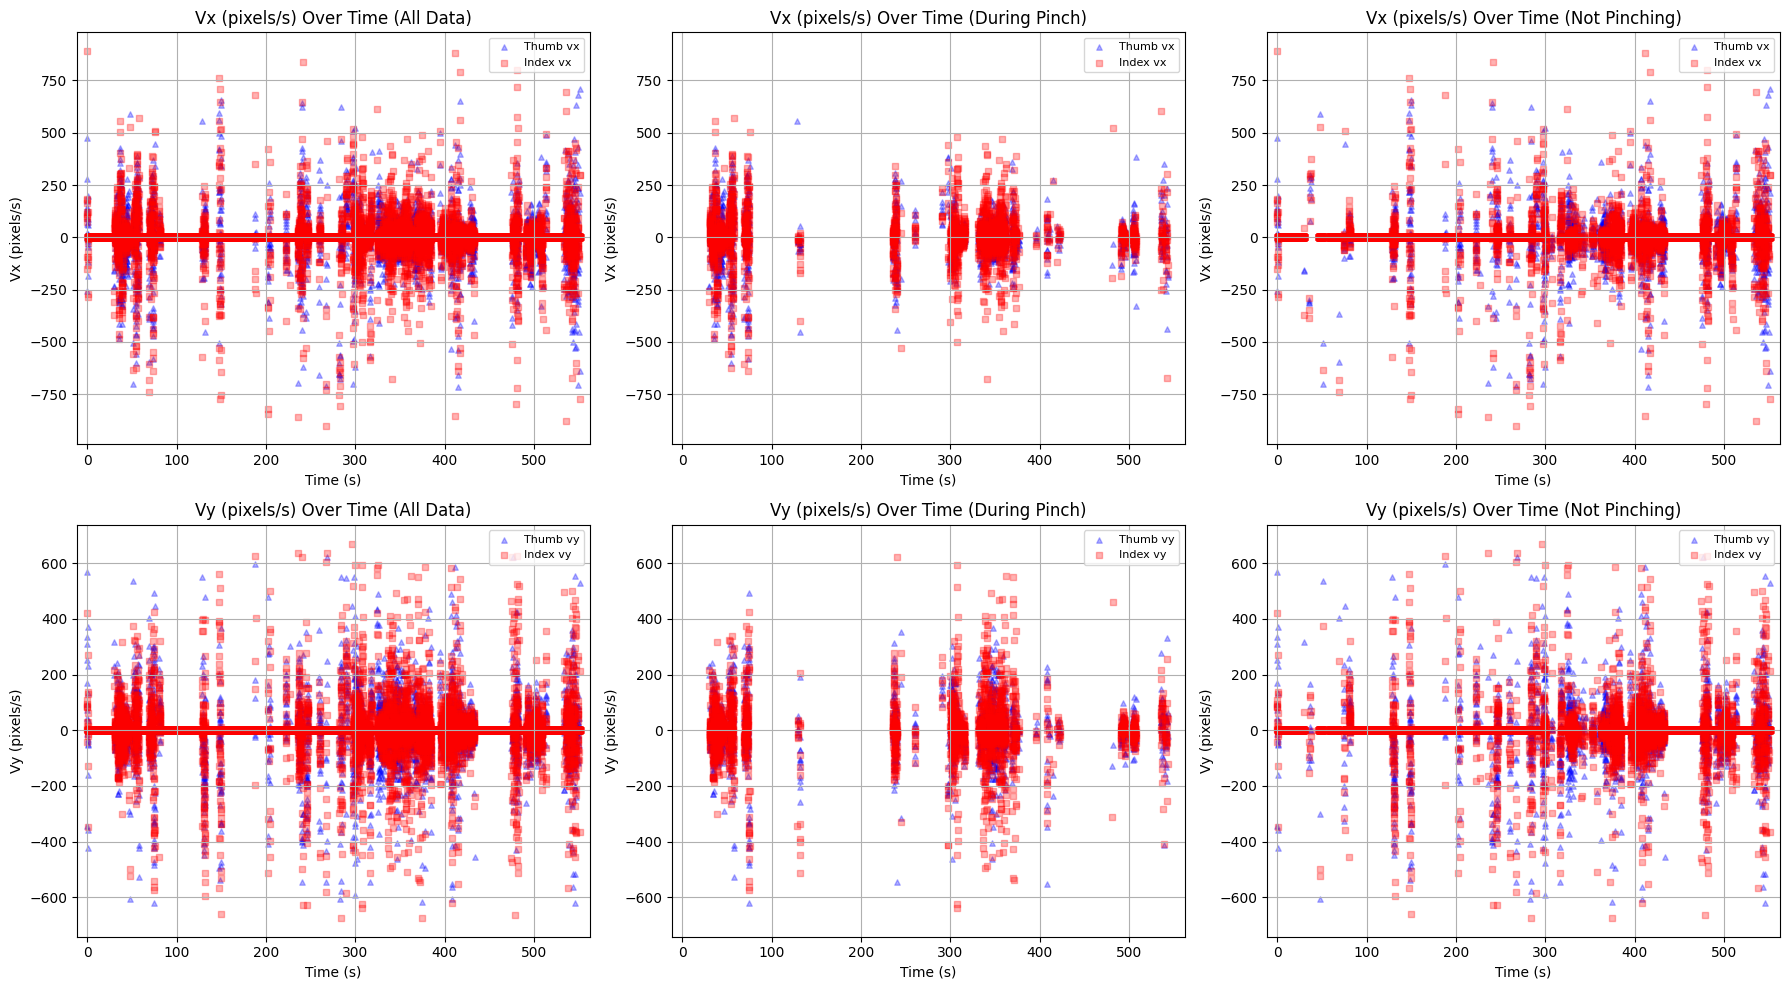

In [86]:
def plot_velocity_over_time(df, figsize=(18, 10)):
    """
    Plot velocity (vx, vy) over time in three subplots:
    1. All data
    2. During interaction
    3. When not interacting
    
    Two rows: Top row for vx, Bottom row for vy
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame with columns: timestamp_numeric, thumb_vx, thumb_vy, active_finger_vx, active_finger_vy, finger, interacting
    figsize : tuple, optional
        Figure size (width, height). Default is (18, 10) for six subplots.
    """
    # Check required columns
    required_cols = {"timestamp_numeric", "thumb_vx", "thumb_vy", "active_finger_vx", "active_finger_vy", "finger"}
    missing = required_cols.difference(df.columns)
    if missing:
        raise ValueError(f"Missing required columns in df: {missing}")
    
    # Finger style mapping (same as position plots)
    finger_style = {
        "index": ("red", "s", "Active finger (Index)"),        # red square
        "middle": ("#90ee90", "*", "Active finger (Middle)"),   # light green star
        "ring": ("darkgreen", "o", "Active finger (Ring)"),    # dark green circle
    }
    
    scatter_size = 18
    thumb_alpha = 0.3
    finger_alpha = 0.3
    
    # Convert timestamp to relative time (seconds from start)
    t0 = df["timestamp_numeric"].min()
    df["time_rel"] = df["timestamp_numeric"] - t0
    
    # Calculate common axis limits from all data
    t_min, t_max = df["time_rel"].min(), df["time_rel"].max()
    
    all_vx = np.concatenate([df["thumb_vx"].dropna().values, df["active_finger_vx"].dropna().values])
    all_vy = np.concatenate([df["thumb_vy"].dropna().values, df["active_finger_vy"].dropna().values])
    
    vx_min, vx_max = np.nanmin(all_vx), np.nanmax(all_vx)
    vy_min, vy_max = np.nanmin(all_vy), np.nanmax(all_vy)
    
    # Add small margin
    t_margin = (t_max - t_min) * 0.02
    vx_margin = (vx_max - vx_min) * 0.05
    vy_margin = (vy_max - vy_min) * 0.05
    
    t_min -= t_margin
    t_max += t_margin
    vx_min -= vx_margin
    vx_max += vx_margin
    vy_min -= vy_margin
    vy_max += vy_margin
    
    # Create figure with 2 rows x 3 columns
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    
    # Helper function to plot velocity on an axis
    def plot_velocity_on_axis(ax, data_df, velocity_col, title_suffix="", ylabel=""):
        # Plot thumb velocity
        thumb_col = f"thumb_{velocity_col}"
        ax.scatter(
            data_df["time_rel"],
            data_df[thumb_col],
            c="blue",
            marker="^",
            label=f"Thumb {velocity_col}",
            alpha=thumb_alpha,
            s=15,
        )
        
        # Plot active finger velocity with different colors/markers per finger type
        active_col = f"active_finger_{velocity_col}"
        for finger_name, (color, marker, label) in finger_style.items():
            mask = data_df["finger"] == finger_name
            if mask.any():
                ax.scatter(
                    data_df.loc[mask, "time_rel"],
                    data_df.loc[mask, active_col],
                    c=color,
                    marker=marker,
                    label=f"{label.split('(')[1].replace(')', '')} {velocity_col}",
                    alpha=finger_alpha,
                    s=scatter_size,
                )
        
        ax.set_xlabel("Time (s)")
        ax.set_ylabel(ylabel)
        ax.set_title(f"{ylabel} Over Time{title_suffix}")
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(True)
        
        # Set same limits for all subplots in the row
        ax.set_xlim(t_min, t_max)
    
    # Helper to handle empty data
    def handle_empty(ax, title, ylim):
        ax.text(0.5, 0.5, "No data", ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title)
        ax.set_xlim(t_min, t_max)
        ax.set_ylim(ylim[0], ylim[1])
    
    # --- Row 1: Vx plots ---
    # Plot 1: All data - Vx
    plot_velocity_on_axis(axes[0, 0], df, "vx", " (All Data)", "Vx (pixels/s)")
    axes[0, 0].set_ylim(vx_min, vx_max)
    
    # Plot 2: During interaction - Vx
    if "interacting" in df.columns:
        interaction_df = df[df["interacting"] == True]
        if not interaction_df.empty:
            plot_velocity_on_axis(axes[0, 1], interaction_df, "vx", " (During Interaction)", "Vx (pixels/s)")
            axes[0, 1].set_ylim(vx_min, vx_max)
        else:
            handle_empty(axes[0, 1], "Vx Over Time (During Interaction)", (vx_min, vx_max))
    else:
        handle_empty(axes[0, 1], "Vx Over Time (During Interaction)", (vx_min, vx_max))
    
    # Plot 3: Not interacting - Vx
    if "interacting" in df.columns:
        not_interaction_df = df[df["interacting"] == False]
        if not not_interaction_df.empty:
            plot_velocity_on_axis(axes[0, 2], not_interaction_df, "vx", " (Not Interacting)", "Vx (pixels/s)")
            axes[0, 2].set_ylim(vx_min, vx_max)
        else:
            handle_empty(axes[0, 2], "Vx Over Time (Not Interacting)", (vx_min, vx_max))
    else:
        handle_empty(axes[0, 2], "Vx Over Time (Not Interacting)", (vx_min, vx_max))
    
    # --- Row 2: Vy plots ---
    # Plot 4: All data - Vy
    plot_velocity_on_axis(axes[1, 0], df, "vy", " (All Data)", "Vy (pixels/s)")
    axes[1, 0].set_ylim(vy_min, vy_max)
    
    # Plot 5: During interaction - Vy
    if "interacting" in df.columns:
        if not interaction_df.empty:
            plot_velocity_on_axis(axes[1, 1], interaction_df, "vy", " (During Interaction)", "Vy (pixels/s)")
            axes[1, 1].set_ylim(vy_min, vy_max)
        else:
            handle_empty(axes[1, 1], "Vy Over Time (During Interaction)", (vy_min, vy_max))
    else:
        handle_empty(axes[1, 1], "Vy Over Time (During Interaction)", (vy_min, vy_max))
    
    # Plot 6: Not interacting - Vy
    if "interacting" in df.columns:
        if not not_interaction_df.empty:
            plot_velocity_on_axis(axes[1, 2], not_interaction_df, "vy", " (Not Interacting)", "Vy (pixels/s)")
            axes[1, 2].set_ylim(vy_min, vy_max)
        else:
            handle_empty(axes[1, 2], "Vy Over Time (Not Interacting)", (vy_min, vy_max))
    else:
        handle_empty(axes[1, 2], "Vy Over Time (Not Interacting)", (vy_min, vy_max))
    
    plt.tight_layout()
    plt.show()

# Call the function to plot velocity over time
plot_velocity_over_time(df)


Using conversion factor: 0.05 cm/pixel
(e.g., 1 pixel = 0.05 cm, or 20.0 pixels = 1 cm)

Thumb mean velocity: vx = 0.0114 cm/s, vy = -0.0704 cm/s
Active finger mean velocity: vx = -0.0284 cm/s, vy = -0.0477 cm/s


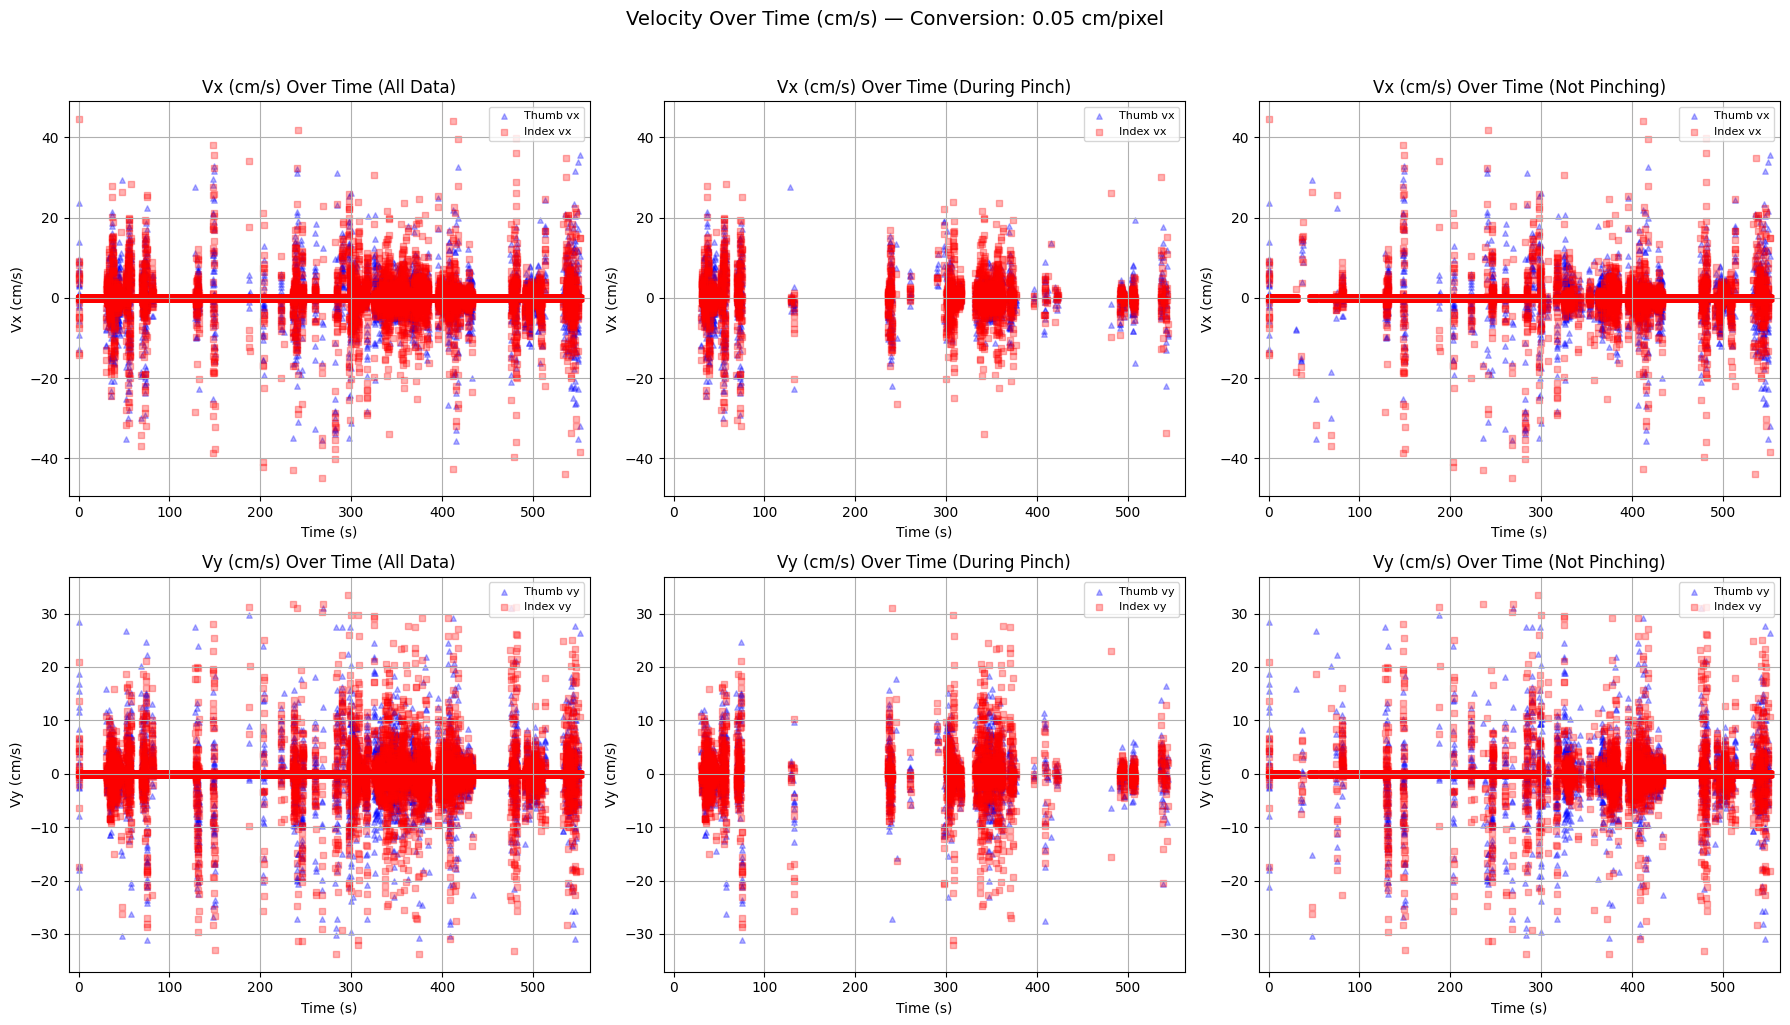

In [87]:
# ============================================================================
# VELOCITY GRAPHS IN CM/S
# ============================================================================

# --- PIXEL TO CM CONVERSION FACTOR ---
# Adjust this value based on your camera calibration.
# Example: if 100 pixels = 1 cm, then PIXELS_TO_CM = 0.01
# To calculate: measure a known distance in the camera view (in cm), 
# then count how many pixels that distance spans. PIXELS_TO_CM = cm / pixels
PIXELS_TO_CM = 0.05  # <-- CHANGE THIS VALUE based on your camera setup

print(f"Using conversion factor: {PIXELS_TO_CM} cm/pixel")
print(f"(e.g., 1 pixel = {PIXELS_TO_CM} cm, or {1/PIXELS_TO_CM:.1f} pixels = 1 cm)")

# Calculate velocities in cm/s
df['thumb_vx_cm'] = df['thumb_vx'] * PIXELS_TO_CM
df['thumb_vy_cm'] = df['thumb_vy'] * PIXELS_TO_CM
df['active_finger_vx_cm'] = df['active_finger_vx'] * PIXELS_TO_CM
df['active_finger_vy_cm'] = df['active_finger_vy'] * PIXELS_TO_CM

# Calculate mean velocities in cm/s
thumb_vx_cm_mean = df['thumb_vx_cm'].mean()
thumb_vy_cm_mean = df['thumb_vy_cm'].mean()
active_finger_vx_cm_mean = df['active_finger_vx_cm'].mean()
active_finger_vy_cm_mean = df['active_finger_vy_cm'].mean()

print(f"\nThumb mean velocity: vx = {thumb_vx_cm_mean:.4f} cm/s, vy = {thumb_vy_cm_mean:.4f} cm/s")
print(f"Active finger mean velocity: vx = {active_finger_vx_cm_mean:.4f} cm/s, vy = {active_finger_vy_cm_mean:.4f} cm/s")

def plot_velocity_over_time_cm(df, pixels_to_cm, figsize=(18, 10)):
    """
    Plot velocity (vx, vy) in cm/s over time in three subplots:
    1. All data
    2. During interaction
    3. When not interacting
    
    Two rows: Top row for vx, Bottom row for vy
    """
    import matplotlib.pyplot as plt
    import numpy as np
    
    # Check required columns
    required_cols = {"timestamp_numeric", "thumb_vx_cm", "thumb_vy_cm", 
                     "active_finger_vx_cm", "active_finger_vy_cm", "finger"}
    missing = required_cols.difference(df.columns)
    if missing:
        raise ValueError(f"Missing required columns in df: {missing}")
    
    # Finger style mapping
    finger_style = {
        "index": ("red", "s", "Active finger (Index)"),
        "middle": ("#90ee90", "*", "Active finger (Middle)"),
        "ring": ("darkgreen", "o", "Active finger (Ring)"),
    }
    
    scatter_size = 18
    thumb_alpha = 0.3
    finger_alpha = 0.3
    
    # Ensure time_rel exists
    if "time_rel" not in df.columns:
        t0 = df["timestamp_numeric"].min()
        df["time_rel"] = df["timestamp_numeric"] - t0
    
    # Calculate common axis limits
    t_min, t_max = df["time_rel"].min(), df["time_rel"].max()
    
    all_vx = np.concatenate([df["thumb_vx_cm"].dropna().values, df["active_finger_vx_cm"].dropna().values])
    all_vy = np.concatenate([df["thumb_vy_cm"].dropna().values, df["active_finger_vy_cm"].dropna().values])
    
    vx_min, vx_max = np.nanmin(all_vx), np.nanmax(all_vx)
    vy_min, vy_max = np.nanmin(all_vy), np.nanmax(all_vy)
    
    # Add small margin
    t_margin = (t_max - t_min) * 0.02
    vx_margin = (vx_max - vx_min) * 0.05
    vy_margin = (vy_max - vy_min) * 0.05
    
    t_min -= t_margin
    t_max += t_margin
    vx_min -= vx_margin
    vx_max += vx_margin
    vy_min -= vy_margin
    vy_max += vy_margin
    
    # Create figure
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    fig.suptitle(f"Velocity Over Time (cm/s) — Conversion: {pixels_to_cm} cm/pixel", fontsize=14, y=1.02)
    
    def plot_velocity_on_axis(ax, data_df, velocity_col, title_suffix="", ylabel=""):
        thumb_col = f"thumb_{velocity_col}_cm"
        ax.scatter(
            data_df["time_rel"],
            data_df[thumb_col],
            c="blue",
            marker="^",
            label=f"Thumb {velocity_col}",
            alpha=thumb_alpha,
            s=15,
        )
        
        active_col = f"active_finger_{velocity_col}_cm"
        for finger_name, (color, marker, label) in finger_style.items():
            mask = data_df["finger"] == finger_name
            if mask.any():
                ax.scatter(
                    data_df.loc[mask, "time_rel"],
                    data_df.loc[mask, active_col],
                    c=color,
                    marker=marker,
                    label=f"{label.split('(')[1].replace(')', '')} {velocity_col}",
                    alpha=finger_alpha,
                    s=scatter_size,
                )
        
        ax.set_xlabel("Time (s)")
        ax.set_ylabel(ylabel)
        ax.set_title(f"{ylabel} Over Time{title_suffix}")
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(True)
        ax.set_xlim(t_min, t_max)
    
    def handle_empty(ax, title, ylim):
        ax.text(0.5, 0.5, "No data", ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title)
        ax.set_xlim(t_min, t_max)
        ax.set_ylim(ylim[0], ylim[1])
    
    # --- Row 1: Vx plots (cm/s) ---
    plot_velocity_on_axis(axes[0, 0], df, "vx", " (All Data)", "Vx (cm/s)")
    axes[0, 0].set_ylim(vx_min, vx_max)
    
    if "interacting" in df.columns:
        interaction_df = df[df["interacting"] == True]
        not_interaction_df = df[df["interacting"] == False]
        
        if not interaction_df.empty:
            plot_velocity_on_axis(axes[0, 1], interaction_df, "vx", " (During Interaction)", "Vx (cm/s)")
            axes[0, 1].set_ylim(vx_min, vx_max)
        else:
            handle_empty(axes[0, 1], "Vx (cm/s) Over Time (During Interaction)", (vx_min, vx_max))
        
        if not not_interaction_df.empty:
            plot_velocity_on_axis(axes[0, 2], not_interaction_df, "vx", " (Not Interacting)", "Vx (cm/s)")
            axes[0, 2].set_ylim(vx_min, vx_max)
        else:
            handle_empty(axes[0, 2], "Vx (cm/s) Over Time (Not Interacting)", (vx_min, vx_max))
    else:
        handle_empty(axes[0, 1], "Vx (cm/s) Over Time (During Interaction)", (vx_min, vx_max))
        handle_empty(axes[0, 2], "Vx (cm/s) Over Time (Not Interacting)", (vx_min, vx_max))
    
    # --- Row 2: Vy plots (cm/s) ---
    plot_velocity_on_axis(axes[1, 0], df, "vy", " (All Data)", "Vy (cm/s)")
    axes[1, 0].set_ylim(vy_min, vy_max)
    
    if "interacting" in df.columns:
        if not interaction_df.empty:
            plot_velocity_on_axis(axes[1, 1], interaction_df, "vy", " (During Interaction)", "Vy (cm/s)")
            axes[1, 1].set_ylim(vy_min, vy_max)
        else:
            handle_empty(axes[1, 1], "Vy (cm/s) Over Time (During Interaction)", (vy_min, vy_max))
        
        if not not_interaction_df.empty:
            plot_velocity_on_axis(axes[1, 2], not_interaction_df, "vy", " (Not Interacting)", "Vy (cm/s)")
            axes[1, 2].set_ylim(vy_min, vy_max)
        else:
            handle_empty(axes[1, 2], "Vy (cm/s) Over Time (Not Interacting)", (vy_min, vy_max))
    else:
        handle_empty(axes[1, 1], "Vy (cm/s) Over Time (During Interaction)", (vy_min, vy_max))
        handle_empty(axes[1, 2], "Vy (cm/s) Over Time (Not Interacting)", (vy_min, vy_max))
    
    plt.tight_layout()
    plt.show()

# Plot velocity graphs in cm/s
plot_velocity_over_time_cm(df, PIXELS_TO_CM)
